# Data Script für die Finanzübersicht

# Daten laden

In [50]:
#pip install pandas

In [51]:
#pip install matplotlib

In [52]:
#pip install lxml

In [53]:
#pip install requests

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import re
from io import StringIO
from matplotlib.backends.backend_svg import FigureCanvasSVG

html = requests.get("https://artstudio-mayer.de/finanzen/").text
tables = pd.read_html(html)

Finanzen_Tablepress = tables[0]
Produktion_Tablepress = tables[1]


# Datenbereinigung - Finanzdaten

In [55]:
Finanzen_Tablepress["Maße"] = Finanzen_Tablepress["Maße"].fillna("")
Finanzen_Tablepress["Menge"] = pd.to_numeric(Finanzen_Tablepress["Menge"], errors="coerce").fillna(0)
Finanzen_Tablepress["Datum"] = pd.to_datetime(Finanzen_Tablepress["Datum"], format="%d.%m.%Y", errors="coerce")
Finanzen_Tablepress["Jahr"] = Finanzen_Tablepress["Datum"].dt.year

def bereinige_betrag(wert):
    try:
        wert = str(wert).replace("€", "").replace(",", ".").replace("–", "").strip()
        return float(wert) if wert else None
    except:
        return None

for spalte in ["Saldo", "Einnahme", "Ausgabe"]:
    Finanzen_Tablepress[spalte] = Finanzen_Tablepress[spalte].apply(bereinige_betrag).fillna(0)


# Gemalte Bilder

In [56]:
gemalte_bilder = (
    Produktion_Tablepress.groupby("Jahr", as_index=False)["Anzahl"]
    .sum()
    .rename(columns={"Anzahl": "gemalte Bilder"})
)

Finanzen_Tablepress = Finanzen_Tablepress.merge(gemalte_bilder, on="Jahr", how="left")
Finanzen_Tablepress["gemalte Bilder"] = Finanzen_Tablepress["gemalte Bilder"].fillna(0).astype(int)


# Jahresübersicht

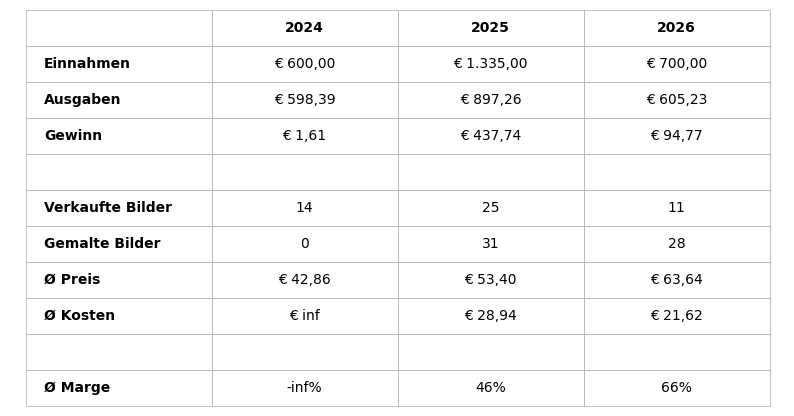

In [57]:
annual_summary = (
    Finanzen_Tablepress.groupby("Jahr")
    .agg(
        Einnahme=("Einnahme", "sum"),
        Ausgabe=("Ausgabe", "sum"),
        Menge=("Menge", "sum"),
        Gemalte_Bilder=("gemalte Bilder", "mean")
    )
    .reset_index()
    .sort_values("Jahr")
    .tail(3)
)

annual_summary["Gewinn"] = annual_summary["Einnahme"] - annual_summary["Ausgabe"]
annual_summary["Ø Preis"] = (annual_summary["Einnahme"] / annual_summary["Menge"]).fillna(0)
annual_summary["Ø Kosten"] = (annual_summary["Ausgabe"] / annual_summary["Gemalte_Bilder"]).fillna(0)
annual_summary["Ø Marge"] = (
    (annual_summary["Ø Preis"] - annual_summary["Ø Kosten"]) /
    annual_summary["Ø Preis"].fillna(0)
)

def euro(x):
    return f"€ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

years = annual_summary["Jahr"].astype(str).tolist()
table_data = [
    ["Einnahmen"] + annual_summary["Einnahme"].map(euro).tolist(),
    ["Ausgaben"] + annual_summary["Ausgabe"].map(euro).tolist(),
    ["Gewinn"] + annual_summary["Gewinn"].map(euro).tolist(),
    [""] * (len(years) + 1),
    ["Verkaufte Bilder"] + annual_summary["Menge"].astype(int).astype(str).tolist(),
    ["Gemalte Bilder"] + annual_summary["Gemalte_Bilder"].astype(int).astype(str).tolist(),
    ["Ø Preis"] + annual_summary["Ø Preis"].map(euro).tolist(),
    ["Ø Kosten"] + annual_summary["Ø Kosten"].map(euro).tolist(),
    [""] * (len(years) + 1),
    ["Ø Marge"] + annual_summary["Ø Marge"].map(lambda x: f"{x:.0%}").replace(float("inf"), "n/a").tolist()
]

fig_Jahresübersicht, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")
table = ax.table(cellText=table_data, colLabels=[""] + years, cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

cells = table.get_celld()
for (row, col), cell in cells.items():
    cell.set_edgecolor("darkgrey")
    cell.set_linewidth(0.5)
    if col == 0:
        cell.get_text().set_ha("left")
    if row == 0 or col == 0:
        cell.get_text().set_weight("bold")

height = cells[(0, 0)].get_height()
width = cells[(0, 0)].get_width()
for cell in cells.values():
    cell.set_height(height * 1.8)
    cell.set_width(width * 0.8)

plt.show()


In [58]:
def save_html(fig, filename, title):
    svg = StringIO()
    FigureCanvasSVG(fig).print_svg(svg)
    with open(filename, "w", encoding="utf-8") as f:
        f.write(f"""<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>{title}</title>
</head>
<body>
{svg.getvalue()}
</body>
</html>""")

save_html(fig_Jahresübersicht, "Jahresübersicht.html", "Jahresübersicht")


# Umsatzstärkstes Quartal – Summe

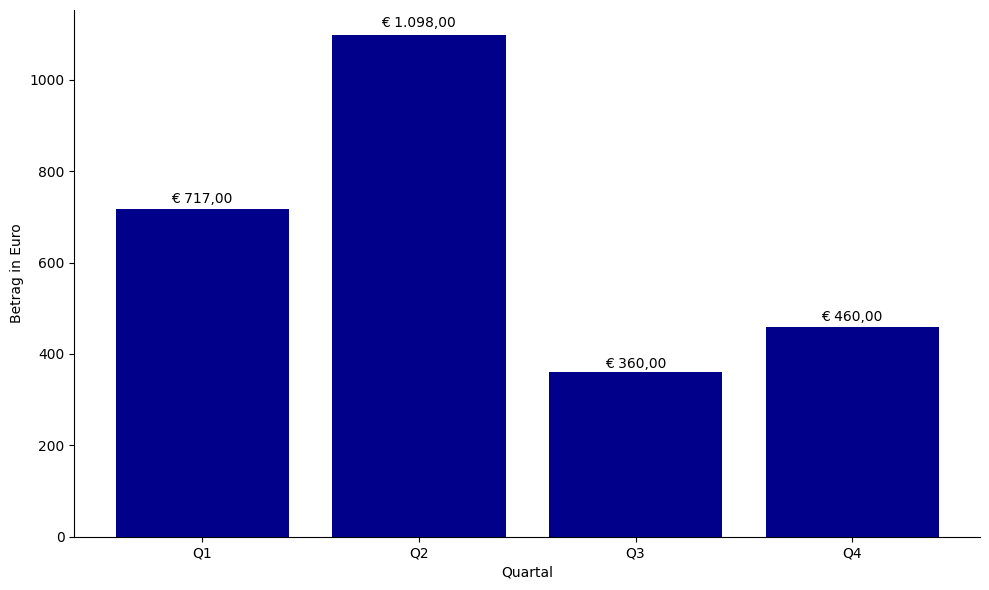

In [59]:
df = Finanzen_Tablepress[Finanzen_Tablepress["Jahr"] >= Finanzen_Tablepress["Jahr"].max() - 2]

einnahmen_quartal = (
    df.groupby(df["Datum"].dt.quarter)["Einnahme"]
    .sum()
    .reindex([1, 2, 3, 4], fill_value=0)
)

labels = ["Q1", "Q2", "Q3", "Q4"]
fig_Umsatzstärkstes_Quartal_summe, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, einnahmen_quartal, color="darkblue")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Betrag in Euro")
ax.set_xlabel("Quartal")

for bar, wert in zip(bars, einnahmen_quartal):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        wert + abs(wert) * 0.01,
        euro(wert),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

save_html(fig_Umsatzstärkstes_Quartal_summe, "Umsatzstärkstes_Quartal.html", "Umsatzstärkstes_Quartal")


# Quartalsübersicht

/var/folders/72/q8l6y1rs3slbdkrbw48hr0vc0000gn/T/ipykernel_1092/490317148.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=90, ha="right")


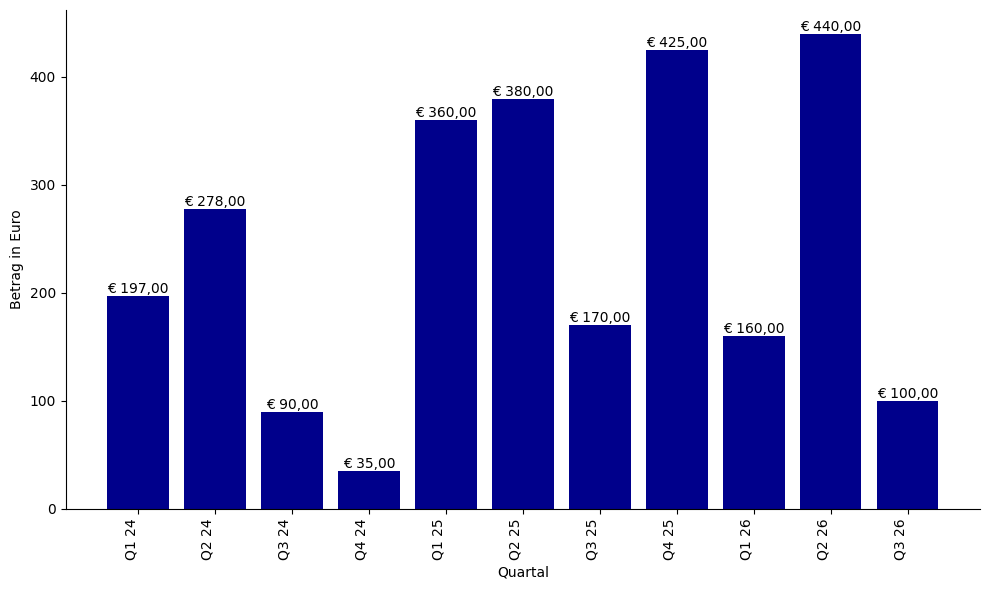

In [60]:
df = Finanzen_Tablepress[Finanzen_Tablepress["Jahr"] >= Finanzen_Tablepress["Jahr"].max() - 2]

einnahmen = df.groupby([df["Datum"].dt.year, df["Datum"].dt.quarter])["Einnahme"].sum()
labels = [f"Q{quartal} {str(jahr)[-2:]}" for jahr, quartal in einnahmen.index]

fig_Quartal, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, einnahmen, color="darkblue")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Betrag in Euro")
ax.set_xlabel("Quartal")
ax.set_xticklabels(labels, rotation=90, ha="right")

for bar, wert in zip(bars, einnahmen):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        wert,
        euro(wert),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

save_html(fig_Quartal, "Quartalsübersicht.html", "Quartalsübersicht")


# Umsatzstärkster Monat – Summe

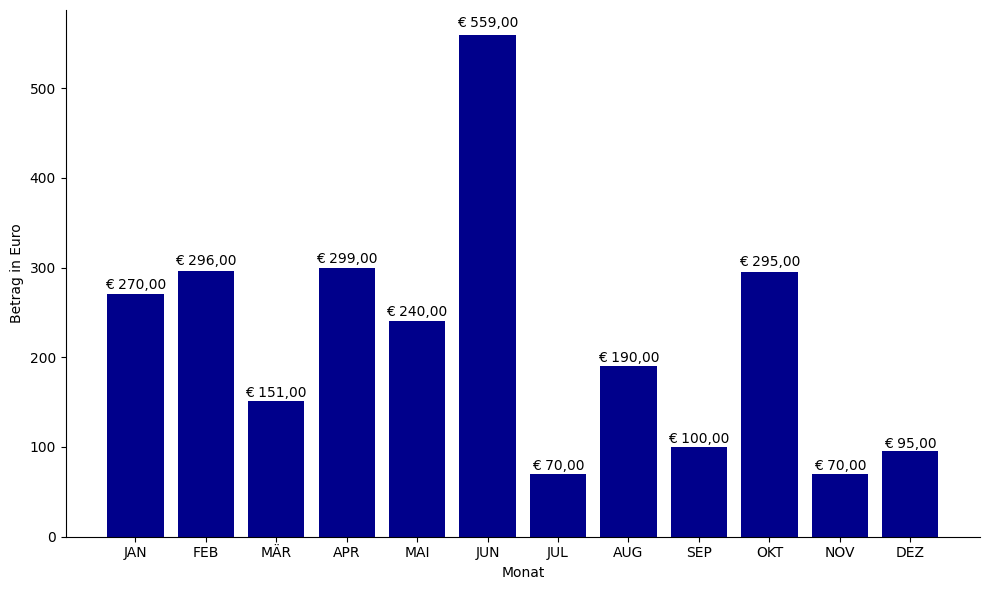

In [61]:
einnahmen_monat = (
    Finanzen_Tablepress.groupby(Finanzen_Tablepress["Datum"].dt.month)["Einnahme"]
    .sum()
    .reindex(range(1, 13), fill_value=0)
)

labels = ["JAN", "FEB", "MÄR", "APR", "MAI", "JUN", "JUL", "AUG", "SEP", "OKT", "NOV", "DEZ"]

fig_Umsatzstärkster_Monat_summe, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, einnahmen_monat, color="darkblue")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Betrag in Euro")
ax.set_xlabel("Monat")

for bar, wert in zip(bars, einnahmen_monat):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        wert + abs(wert) * 0.01,
        euro(wert),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

save_html(fig_Umsatzstärkster_Monat_summe, "Umsatzstärkster_Monat.html", "Umsatzstärkster_Monat")


# Monatsübersicht

/var/folders/72/q8l6y1rs3slbdkrbw48hr0vc0000gn/T/ipykernel_1092/1520849001.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=90, ha="right")


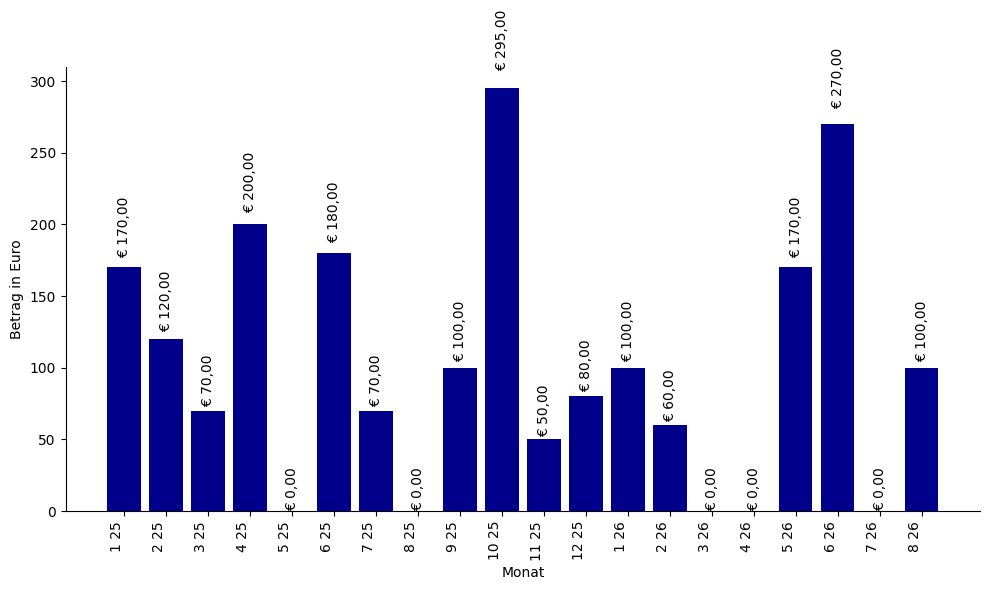

In [62]:
df = Finanzen_Tablepress[Finanzen_Tablepress["Jahr"] >= Finanzen_Tablepress["Jahr"].max() - 1]

einnahmen = df.groupby([df["Datum"].dt.year, df["Datum"].dt.month])["Einnahme"].sum()
labels = [f"{month} {str(jahr)[-2:]}" for jahr, month in einnahmen.index]

fig_Monat, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, einnahmen, color="darkblue")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Betrag in Euro")
ax.set_xlabel("Monat")
ax.set_xticklabels(labels, rotation=90, ha="right")

for bar, wert in zip(bars, einnahmen):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        wert + abs(wert) * 0.04,
        euro(wert),
        ha="center",
        va="bottom",
        rotation=90
    )

plt.tight_layout()
plt.show()

save_html(fig_Monat, "Monatsübersicht.html", "Monatsübersicht")


# Umsatzstärkster Verkaufskanal – Summe

/var/folders/72/q8l6y1rs3slbdkrbw48hr0vc0000gn/T/ipykernel_1092/2550402298.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(einnahmen.index, rotation=90, ha="right")


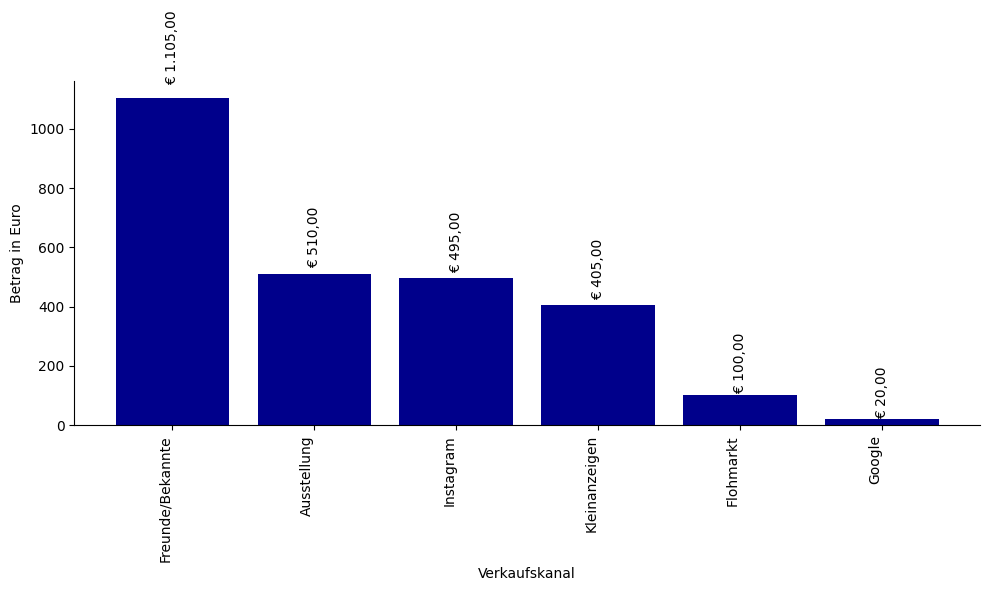

In [63]:
df = Finanzen_Tablepress[Finanzen_Tablepress["Kategorie"] == "Einnahmen"]

einnahmen = (
    df.groupby(df["Klassifizierung"].astype(str))["Einnahme"]
    .sum()
    .sort_values(ascending=False)
)

fig_Umsatzstärkster_Verkaufskanal_summe, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(einnahmen.index, einnahmen, color="darkblue")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Betrag in Euro")
ax.set_xlabel("Verkaufskanal")
ax.set_xticklabels(einnahmen.index, rotation=90, ha="right")

for bar, wert in zip(bars, einnahmen):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        wert + abs(wert) * 0.04,
        euro(wert),
        ha="center",
        va="bottom",
        rotation=90
    )

plt.tight_layout()
plt.show()

save_html(fig_Umsatzstärkster_Verkaufskanal_summe, "Umsatzstärkster_Verkaufskanal.html", "Umsatzstärkster_Verkaufskanal")


# Umsatzstärkster Verkaufskanal pro Jahr

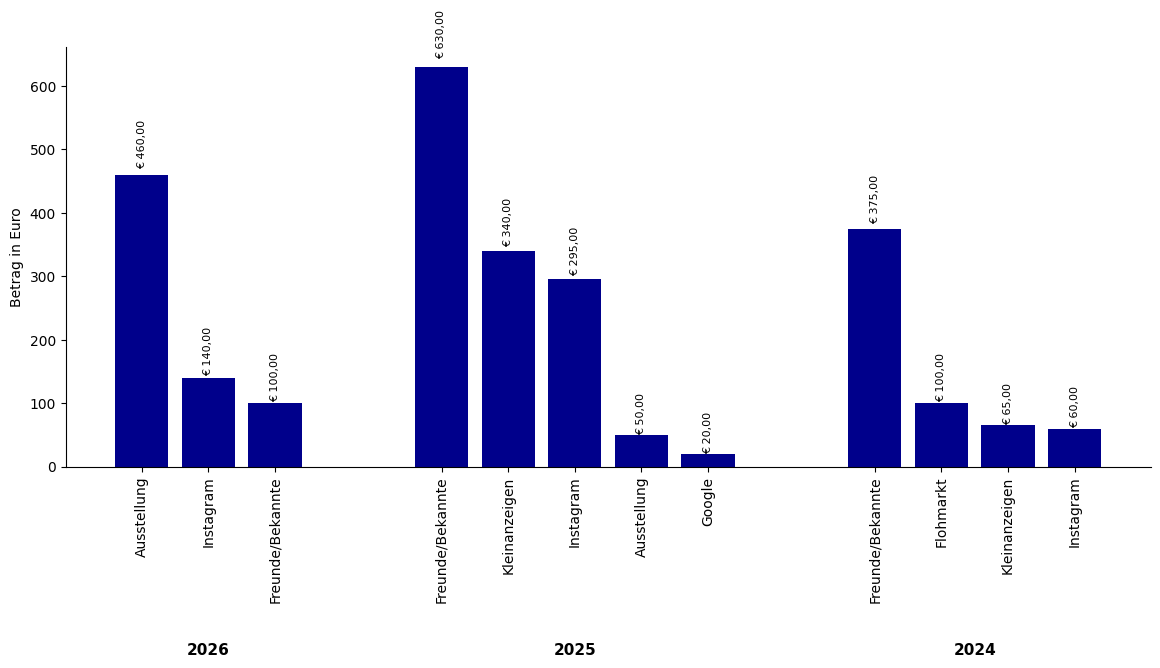

In [64]:
df = Finanzen_Tablepress[Finanzen_Tablepress["Kategorie"] == "Einnahmen"].copy()
df["Jahr"] = pd.to_datetime(df["Datum"]).dt.year

letzte_3_jahre = sorted(df["Jahr"].dropna().unique(), reverse=True)[:3]
einnahmen = df.groupby(["Jahr", "Klassifizierung"])["Einnahme"].sum().reset_index()

x_positionen, labels_kanal, werte, jahr_mittelpunkte = [], [], [], []
aktuelle_position = 0

for jahr in letzte_3_jahre:
    daten_jahr = einnahmen[einnahmen["Jahr"] == jahr].sort_values("Einnahme", ascending=False)
    start = aktuelle_position

    for _, zeile in daten_jahr.iterrows():
        x_positionen.append(aktuelle_position)
        labels_kanal.append(str(zeile["Klassifizierung"]))
        werte.append(zeile["Einnahme"])
        aktuelle_position += 1

    jahr_mittelpunkte.append((start + aktuelle_position - 1) / 2)
    aktuelle_position += 1.5

fig_Umsatzstärkster_Verkaufskanal, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(x_positionen, werte, width=0.8, color="darkblue")

for bar, wert in zip(bars, werte):
    if wert != 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            wert + abs(wert) * 0.02,
            euro(wert),
            ha="center",
            va="bottom",
            rotation=90,
            fontsize=8
        )

ax.set_xticks(x_positionen)
ax.set_xticklabels(labels_kanal, rotation=90, ha="center")
ax.set_ylabel("Betrag in Euro")

for jahr, mittelpunkt in zip(letzte_3_jahre, jahr_mittelpunkte):
    ax.text(
        mittelpunkt, -0.42, str(jahr),
        transform=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=11, fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.subplots_adjust(bottom=0.28)
plt.show()

save_html(
    fig_Umsatzstärkster_Verkaufskanal,
    "Umsatzstärkster_Verkaufskanal_pro_Jahr.html",
    "Umsatzstärkster_Verkaufskanal_pro_Jahr"
)


# Umsatzstärkste Ausstellung

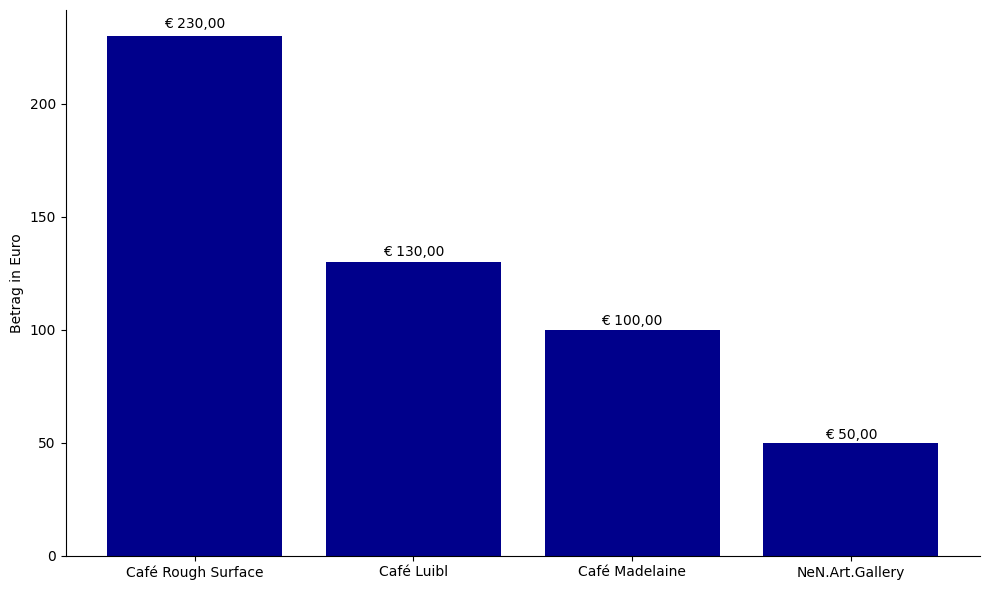

In [65]:
df = Finanzen_Tablepress[
    (Finanzen_Tablepress["Klassifizierung"] == "Ausstellung") &
    (Finanzen_Tablepress["Kategorie"] == "Einnahmen")
]

einnahmen_ausstellung = (
    df.groupby(df["Notiz"].astype(str))["Einnahme"]
    .sum()
    .sort_values(ascending=False)
)

labels_kurz = [re.sub(r"\s*\(.*?\)", "", str(label)).strip() for label in einnahmen_ausstellung.index]

fig_Umsatzstärkste_Ausstellung, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels_kurz, einnahmen_ausstellung, color="darkblue")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Betrag in Euro")

for bar, wert in zip(bars, einnahmen_ausstellung):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        wert + abs(wert) * 0.01,
        euro(wert),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

save_html(fig_Umsatzstärkste_Ausstellung, "Umsatzstärkste_Ausstellung.html", "Umsatzstärkste_Ausstellung")


# Jahresübersicht mobile

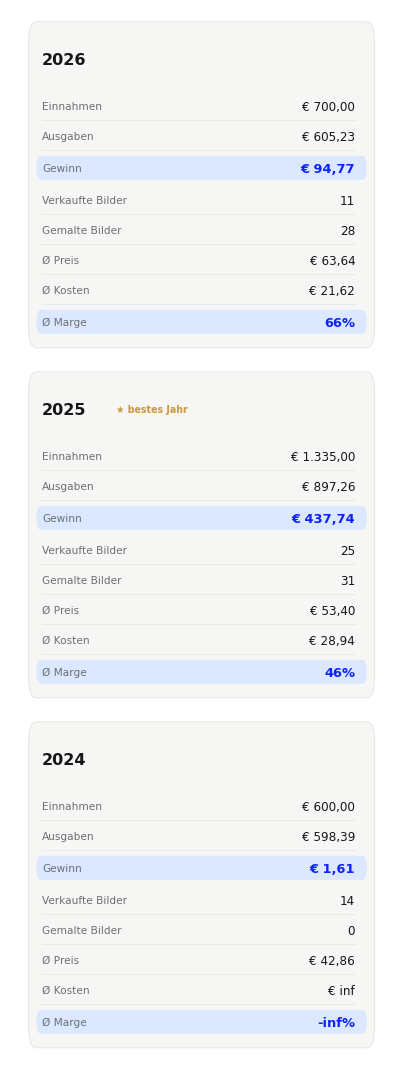

In [66]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.backends.backend_svg import FigureCanvasSVG
from io import StringIO
# Finanzen_Tablepress muss bereits in deinem Notebook existieren

# ---------- Farben ----------
FARBE_TEXT     = "#15171B"
FARBE_GRAU     = "#6B6F76"
FARBE_KARTE    = "#F6F6F4"
FARBE_KARTE_R  = "#E6E6E2"
FARBE_KEY_BG   = "#DBE8FF"
FARBE_KEY_TEXT = "#0E22FE"
FARBE_LINIE    = "#E4E4E1"
FARBE_BADGE_BG = "#DBE8FF"
FARBE_GOLD     = "#C89B3C"

# ---------- Daten (unverändert) ----------
annual_summary = (
    Finanzen_Tablepress.groupby("Jahr")
    .agg(
        Einnahme=("Einnahme", "sum"),
        Ausgabe=("Ausgabe", "sum"),
        Menge=("Menge", "sum"),
        Gemalte_Bilder=("gemalte Bilder", "mean")
    )
    .reset_index()
    .sort_values("Jahr")
    .tail(3)
)

annual_summary["Gewinn"] = annual_summary["Einnahme"] - annual_summary["Ausgabe"]
annual_summary["Ø Preis"] = (annual_summary["Einnahme"] / annual_summary["Menge"]).fillna(0)
annual_summary["Ø Kosten"] = (annual_summary["Ausgabe"] / annual_summary["Gemalte_Bilder"]).fillna(0)
annual_summary["Ø Marge"] = (
    (annual_summary["Ø Preis"] - annual_summary["Ø Kosten"]) /
    annual_summary["Ø Preis"].fillna(0)
)

def euro(x):
    return f"€ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

def prozent(x):
    return f"{x:.0%}"

annual_summary = annual_summary.sort_values("Jahr", ascending=False).reset_index(drop=True)
jahre = annual_summary["Jahr"].astype(int).tolist()

# Zeilen je Karte: (Beschriftung, Wert-Funktion, ist_key_zeile)
zeilen_defs = [
    ("Einnahmen",        lambda r: euro(r["Einnahme"]),                         False),
    ("Ausgaben",         lambda r: euro(r["Ausgabe"]),                          False),
    ("Gewinn",           lambda r: euro(r["Gewinn"]),                           True),
    ("Verkaufte Bilder", lambda r: str(int(r["Menge"])),                        False),
    ("Gemalte Bilder",   lambda r: str(int(r["Gemalte_Bilder"])),               False),
    ("Ø Preis",          lambda r: euro(r["Ø Preis"]),                          False),
    ("Ø Kosten",         lambda r: euro(r["Ø Kosten"]),                         False),
    ("Ø Marge",          lambda r: prozent(r["Ø Marge"]) if r["Ø Preis"] else "n/a", True),
]

# ---------- Layout-Berechnung in Punkt (unabhängig von der Bildhöhe) ----------
ZEILE_H       = 30     # Höhe einer normalen Zeile
KEY_ZEILE_H   = 34     # Höhe einer hervorgehobenen Zeile (Gewinn, Ø Marge)
KOPF_H        = 46     # Platz für die Jahreszahl oben in der Karte
KARTE_PAD     = 16     # Innenabstand oben/unten in der Karte
KARTEN_ABSTAND = 24    # Abstand zwischen zwei Karten
SEITEN_RAND   = 15     # Platz für Titel oben

zeilen_hoehe_summe = sum(KEY_ZEILE_H if key else ZEILE_H for _, _, key in zeilen_defs)
karten_hoehe_pt = KOPF_H + zeilen_hoehe_summe + 2 * KARTE_PAD

n_jahre = len(jahre)
gesamt_hoehe_pt = SEITEN_RAND + n_jahre * karten_hoehe_pt + (n_jahre - 1) * KARTEN_ABSTAND + 30

FIG_H = gesamt_hoehe_pt / 72          # Zoll
FIG_W = 5.4

def pt(p):
    return p / 72 / FIG_H

fig_Jahresübersicht_mobile = plt.figure(figsize=(FIG_W, FIG_H), dpi=150)
ax = fig_Jahresübersicht_mobile.add_axes([0, 0, 1, 1])
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
fig_Jahresübersicht_mobile.patch.set_facecolor("white")
ax.set_facecolor("white")

# ---------- Titel ----------
#ax.text(0.055, 1 - pt(30), "JAHRESÜBERSICHT", fontsize=19, fontweight="bold", color=FARBE_TEXT)
#ax.text(0.055, 1 - pt(50), f"{jahre[-1]}\u2013{jahre[0]}", fontsize=11.5, color=FARBE_GRAU)

# ---------- Karten ----------
karten_hoehe = pt(karten_hoehe_pt)
karten_abstand = pt(KARTEN_ABSTAND)
top = 1 - pt(SEITEN_RAND)

bester_gewinn = annual_summary["Gewinn"].max()

for i, jahr in enumerate(jahre):
    row = annual_summary.iloc[i]
    y = top - i * (karten_hoehe + karten_abstand) - karten_hoehe

    ax.add_patch(FancyBboxPatch(
        (0.055, y), 0.89, karten_hoehe,
        boxstyle=f"round,pad=0,rounding_size=0.02",
        linewidth=1, edgecolor=FARBE_KARTE_R, facecolor=FARBE_KARTE
    ))

    kopf_y = y + karten_hoehe - pt(KARTE_PAD) - pt(22)
    ax.text(0.09, kopf_y, str(jahr), fontsize=16, fontweight="bold", color=FARBE_TEXT, va="center")
    if row["Gewinn"] == bester_gewinn:
        ax.text(0.09 + 0.19, kopf_y, "★ bestes Jahr", fontsize=9.5, fontweight="bold",
                color=FARBE_GOLD, va="center")

    aktuelle_y = kopf_y - pt(32)
    for label, wert_fn, ist_key in zeilen_defs:
        zeile_h = KEY_ZEILE_H if ist_key else ZEILE_H
        wert = wert_fn(row)

        if ist_key:
            ax.add_patch(FancyBboxPatch(
                (0.075, aktuelle_y - pt(zeile_h) + pt(6)), 0.85, pt(zeile_h) - pt(10),
                boxstyle="round,pad=0,rounding_size=0.012",
                linewidth=0, facecolor=FARBE_KEY_BG
            ))
            farbe = FARBE_KEY_TEXT
            gewicht = "bold"
            groesse = 13
        else:
            farbe = FARBE_TEXT
            gewicht = "normal"
            groesse = 12
            # dünne Trennlinie unter normalen Zeilen
            ax.plot([0.09, 0.895], [aktuelle_y - pt(zeile_h) + pt(2), aktuelle_y - pt(zeile_h) + pt(2)],
                    color=FARBE_LINIE, linewidth=0.7)

        mitte_y = aktuelle_y - pt(zeile_h) / 2
        ax.text(0.09, mitte_y, label, fontsize=10.5, color=FARBE_GRAU, va="center")
        ax.text(0.895, mitte_y, wert, fontsize=groesse, fontweight=gewicht,
                color=farbe, va="center", ha="right")

        aktuelle_y -= pt(zeile_h)

svg = StringIO()
FigureCanvasSVG(fig_Jahresübersicht_mobile).print_svg(svg)


In [ ]:
save_html(
    fig_Jahresübersicht_mobile,
    "Jahresübersicht_mobile.html",
    "Jahresübersicht_mobile"
)

# Umsatzstärkster Verkaufskanal mobile

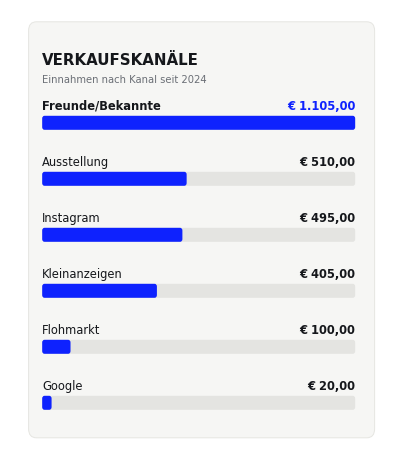

In [68]:
# ---------- Farben (identisch zur "Jahresübersicht Mobile") ----------
FARBE_TEXT     = "#15171B"
FARBE_GRAU     = "#6B6F76"
FARBE_KARTE    = "#F6F6F4"
FARBE_KARTE_R  = "#E6E6E2"
FARBE_KEY_BG   = "#EAF1E7"
FARBE_KEY_TEXT = "#0E22FE"
FARBE_LINIE    = "#E4E4E1"
FARBE_GOLD     = "#C89B3C"

def euro(x):
    return f"€ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

# ---------- Daten (unverändert) ----------
df = Finanzen_Tablepress.copy()
df = df[df['Kategorie'] == 'Einnahmen']

einnahmen = (
    df.groupby([df['Klassifizierung'].astype(str)])['Einnahme']
    .sum()
    .sort_values(ascending=False)
)

kanaele = einnahmen.index.tolist()
werte = einnahmen.tolist()
max_wert = max(werte)
n = len(kanaele)

# ---------- Layout-Berechnung in Punkt (unabhängig von der Bildhöhe) ----------
ZEILE_H        = 56     # Höhe je Kanal-Zeile (Label + Balken)
KOPF_H         = 44     # Platz für Titel im Kartenkopf
KARTE_PAD      = 18     # Innenabstand oben/unten in der Karte
SEITEN_RAND    = 15     # Platz oberhalb der Karte

karten_hoehe_pt = KOPF_H + n * ZEILE_H + 2 * KARTE_PAD
gesamt_hoehe_pt = SEITEN_RAND + karten_hoehe_pt + 20

FIG_W = 5.4
FIG_H = gesamt_hoehe_pt / 72

def pt(p):
    return p / 72 / FIG_H

fig_Umsatzstärkster_Verkaufskanal_mobile = plt.figure(figsize=(FIG_W, FIG_H), dpi=150)
ax = fig_Umsatzstärkster_Verkaufskanal_mobile.add_axes([0, 0, 1, 1])
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
fig_Umsatzstärkster_Verkaufskanal_mobile.patch.set_facecolor("white")
ax.set_facecolor("white")

karten_hoehe = pt(karten_hoehe_pt)
top = 1 - pt(SEITEN_RAND)
y_karte = top - karten_hoehe

ax.add_patch(FancyBboxPatch(
    (0.055, y_karte), 0.89, karten_hoehe,
    boxstyle="round,pad=0,rounding_size=0.02",
    linewidth=1, edgecolor=FARBE_KARTE_R, facecolor=FARBE_KARTE
))

# ---------- Kartenkopf ----------
kopf_y = top - pt(KARTE_PAD) - pt(20)
ax.text(0.09, kopf_y, "VERKAUFSKANÄLE", fontsize=15, fontweight="bold", color=FARBE_TEXT, va="center")
ax.text(0.09, kopf_y - pt(20), "Einnahmen nach Kanal seit 2024", fontsize=10, color=FARBE_GRAU, va="center")

# ---------- Balken-Zeilen ----------
BALKEN_X0 = 0.09
BALKEN_X1 = 0.895
BALKEN_BREITE_MAX = BALKEN_X1 - BALKEN_X0
BALKEN_HOEHE = pt(14)

aktuelle_y = kopf_y - pt(46)
for i, (kanal, wert) in enumerate(zip(kanaele, werte)):
    zeile_top = aktuelle_y

    ist_top = (i == 0)
    label_farbe = FARBE_KEY_TEXT if ist_top else FARBE_TEXT

    # Kanalname + Wert
    ax.text(BALKEN_X0, zeile_top, kanal, fontsize=11.5, fontweight="bold" if ist_top else "normal",
            color=FARBE_TEXT, va="center")
    if ist_top:
        ax.text(BALKEN_X0 + 0.02 + 0.017 * len(kanal), zeile_top, "", fontsize=10.5,
                color=FARBE_GOLD, va="center")
    ax.text(BALKEN_X1, zeile_top, euro(wert), fontsize=11.5, fontweight="bold",
            color=label_farbe, va="center", ha="right")

    # Balken-Track (Hintergrund)
    balken_y = zeile_top - pt(24)
    ax.add_patch(FancyBboxPatch(
        (BALKEN_X0, balken_y), BALKEN_BREITE_MAX, BALKEN_HOEHE,
        boxstyle="round,pad=0,rounding_size=0.006",
        linewidth=0, facecolor=FARBE_LINIE
    ))
    # Gefüllter Balken (Anteil am Maximum)
    anteil = max(wert / max_wert, 0.03)
    ax.add_patch(FancyBboxPatch(
        (BALKEN_X0, balken_y), BALKEN_BREITE_MAX * anteil, BALKEN_HOEHE,
        boxstyle="round,pad=0,rounding_size=0.006",
        linewidth=0, facecolor=FARBE_KEY_TEXT if ist_top else "#0E22FE"
    ))

    aktuelle_y -= pt(ZEILE_H)

svg = StringIO()
FigureCanvasSVG(fig_Umsatzstärkster_Verkaufskanal_mobile).print_svg(svg)

In [ ]:
save_html(
    fig_Umsatzstärkster_Verkaufskanal_mobile,
    "Umsatzstärkster_Verkaufskanal_mobile.html",
    "Umsatzstärkster_Verkaufskanal_mobile"
)

# Umsatzstärkste Ausstellung mobile

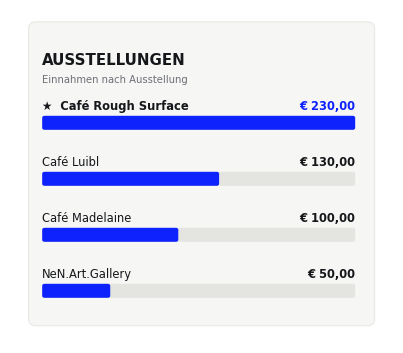

In [70]:
# ---------- Farben (identisch zur "Jahresübersicht Mobile") ----------
FARBE_TEXT     = "#15171B"
FARBE_GRAU     = "#6B6F76"
FARBE_KARTE    = "#F6F6F4"
FARBE_KARTE_R  = "#E6E6E2"
FARBE_KEY_BG   = "#EAF1E7"
FARBE_KEY_TEXT = "#0E22FE"
FARBE_LINIE    = "#E4E4E1"
FARBE_GOLD     = "#C89B3C"

def euro(x):
    return f"€ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

# ---------- Daten (unverändert) ----------
df = Finanzen_Tablepress[
    (Finanzen_Tablepress["Klassifizierung"] == "Ausstellung") &
    (Finanzen_Tablepress["Kategorie"] == "Einnahmen")
]

einnahmen_ausstellung = (
    df.groupby(df["Notiz"].astype(str))["Einnahme"]
    .sum()
    .sort_values(ascending=False)
)

labels_kurz = [re.sub(r"\s*\(.*?\)", "", str(label)).strip() for label in einnahmen_ausstellung.index]
werte = einnahmen_ausstellung.tolist()
max_wert = max(werte)
n = len(labels_kurz)
 
# ---------- Layout-Berechnung in Punkt (unabhängig von der Bildhöhe) ----------
ZEILE_H        = 56     # Höhe je Ausstellungs-Zeile (Label + Balken)
KOPF_H         = 44     # Platz für Titel im Kartenkopf
KARTE_PAD      = 18     # Innenabstand oben/unten in der Karte
SEITEN_RAND    = 15     # Platz oberhalb der Karte
 
karten_hoehe_pt = KOPF_H + n * ZEILE_H + 2 * KARTE_PAD
gesamt_hoehe_pt = SEITEN_RAND + karten_hoehe_pt + 20
 
FIG_W = 5.4
FIG_H = gesamt_hoehe_pt / 72
 
def pt(p):
    return p / 72 / FIG_H
 
fig_Umsatzstärkste_Ausstellung_mobile = plt.figure(figsize=(FIG_W, FIG_H), dpi=150)
ax = fig_Umsatzstärkste_Ausstellung_mobile.add_axes([0, 0, 1, 1])
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
fig_Umsatzstärkste_Ausstellung_mobile.patch.set_facecolor("white")
ax.set_facecolor("white")
 
karten_hoehe = pt(karten_hoehe_pt)
top = 1 - pt(SEITEN_RAND)
y_karte = top - karten_hoehe
 
ax.add_patch(FancyBboxPatch(
    (0.055, y_karte), 0.89, karten_hoehe,
    boxstyle="round,pad=0,rounding_size=0.02",
    linewidth=1, edgecolor=FARBE_KARTE_R, facecolor=FARBE_KARTE
))
 
# ---------- Kartenkopf ----------
kopf_y = top - pt(KARTE_PAD) - pt(20)
ax.text(0.09, kopf_y, "AUSSTELLUNGEN", fontsize=15, fontweight="bold", color=FARBE_TEXT, va="center")
ax.text(0.09, kopf_y - pt(20), "Einnahmen nach Ausstellung", fontsize=10, color=FARBE_GRAU, va="center")
 
# ---------- Balken-Zeilen ----------
BALKEN_X0 = 0.09
BALKEN_X1 = 0.895
BALKEN_BREITE_MAX = BALKEN_X1 - BALKEN_X0
BALKEN_HOEHE = pt(14)
 
aktuelle_y = kopf_y - pt(46)
for i, (label, wert) in enumerate(zip(labels_kurz, werte)):
    zeile_top = aktuelle_y
 
    ist_top = (i == 0)
    label_farbe = FARBE_KEY_TEXT if ist_top else FARBE_TEXT
 
    # Ausstellungsname + Wert
    label_text = f"★  {label}" if ist_top else label
    ax.text(BALKEN_X0, zeile_top, label_text, fontsize=11.5, fontweight="bold" if ist_top else "normal",
            color=FARBE_TEXT, va="center")
    ax.text(BALKEN_X1, zeile_top, euro(wert), fontsize=11.5, fontweight="bold",
            color=label_farbe, va="center", ha="right")
 
    # Balken-Track (Hintergrund)
    balken_y = zeile_top - pt(24)
    ax.add_patch(FancyBboxPatch(
        (BALKEN_X0, balken_y), BALKEN_BREITE_MAX, BALKEN_HOEHE,
        boxstyle="round,pad=0,rounding_size=0.006",
        linewidth=0, facecolor=FARBE_LINIE
    ))
    # Gefüllter Balken (Anteil am Maximum)
    anteil = max(wert / max_wert, 0.03)
    ax.add_patch(FancyBboxPatch(
        (BALKEN_X0, balken_y), BALKEN_BREITE_MAX * anteil, BALKEN_HOEHE,
        boxstyle="round,pad=0,rounding_size=0.006",
        linewidth=0, facecolor=FARBE_KEY_TEXT if ist_top else "#0E22FE"
    ))
 
    aktuelle_y -= pt(ZEILE_H)
 
svg = StringIO()
FigureCanvasSVG(fig_Umsatzstärkste_Ausstellung_mobile).print_svg(svg)

In [71]:
save_html(
    fig_Umsatzstärkste_Ausstellung_mobile,
    "Umsatzstärkste_Ausstellung_mobile.html",
    "Umsatzstärkste_Ausstellung mobile"
)